In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Demola\Desktop\potfolio data\Sample - Superstore.csv',encoding = 'latin-1')

In [3]:
#BASIC SHAPE
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0


In [4]:
#I FOUND OUT THAT THERE ARE NO MISSING VALUES,BUT ORDER DATES AND SHIP DATES ARE STORED IN STRINGS,THEY NEED TO BE CHANGED.
#POSTAL CODE IS NUMERIC AND SHOULD BE TREATED AS A STRING

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [5]:
#FIXING POSTAL CODE DATA TYPE

df['Postal Code'] = df['Postal Code'].astype(str).str.zfill(5)

In [6]:
# TO EXTRACT YEAR, MONTH,MONTH NAME

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)

df['Days to ship'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin(%)'] = (df['Profit']/df['Sales']) * 100
df['Revenue per Unit'] = df['Sales']/df['Quantity']

In [7]:
#TO VIEW THE CHANGES MADE 
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(9994, 28)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Month Name', 'Quarter', 'Days to ship', 'Profit Margin(%)', 'Revenue per Unit']
Row ID                       int64
Order ID                    object
Order Date          datetime64[ns]
Ship Date           datetime64[ns]
Ship Mode                   object
Customer ID                 object
Customer Name               object
Segment                     object
Country                     object
City                        object
State                       object
Postal Code                 object
Region                      object
Product ID                  object
Category                    object
Sub-Category                object
Product Name                object
Sales                      float64
Q

In [8]:
# TO VALIDATE FINANCIAL LOGIC
negative_profit= df[df['Profit'] < 0]
print(f"loss making orders : {len(negative_profit)}")

loss making orders : 1871


In [13]:
# EXPLORATORY DATA ANALYSIS

# 1. To get the overall sales and profit trends by year

yearly = df.groupby('Year').agg(
    Total_Sales = ('Sales','sum'),
    Total_profit = ('Profit','sum'),
    Orders =('Order ID','nunique')
).reset_index()

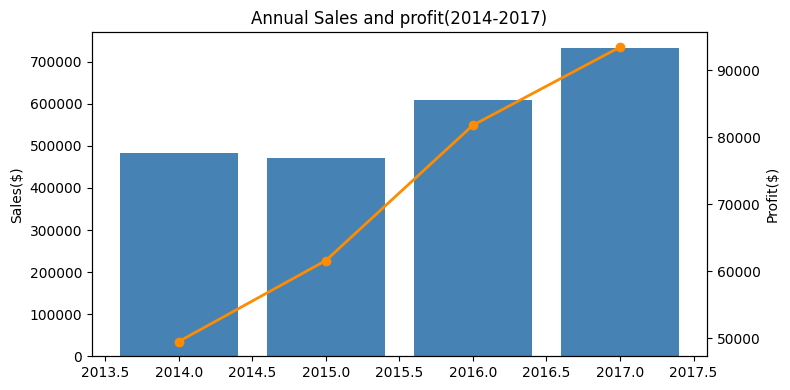

In [18]:
#Chart for the above
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(figsize = (8,4))
ax.bar(yearly['Year'],yearly['Total_Sales'],color='steelblue', label='Sales')
ax2 = ax.twinx()
ax2.plot(yearly['Year'],yearly['Total_profit'],color='darkorange',marker='o',linewidth=2,label='Profit')
ax.set_title('Annual Sales and profit(2014-2017)')
ax2.set_ylabel('Profit($)')
ax.set_ylabel('Sales($)')
plt.tight_layout()
plt.show()

In [21]:
#WHICH PRODUCT CATEGORY AND SUB CATEGORY DRIVES THE MOST AND THE LEAST PROFIT

cat_profit = df.groupby('Category')['Profit'].sum().sort_values()
print(cat_profit)
subcat = df.groupby('Sub-Category').agg(
    sales=('Sales','sum'),
    Profit = ('Profit','sum')
).sort_values('Profit')

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


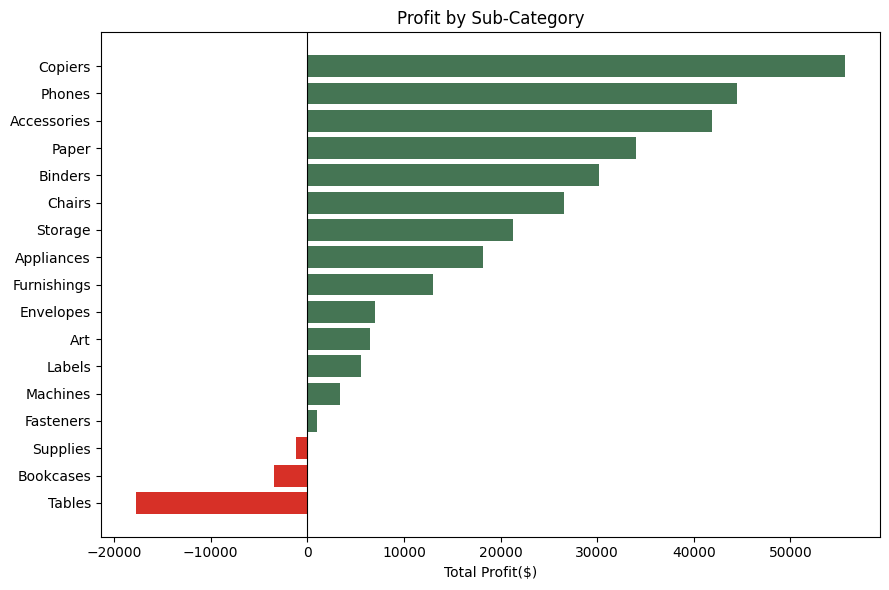

In [24]:
# Horizontal bar-chart

fig,ax = plt.subplots(figsize=(9,6))
colors = ['#d73027' if x < 0 else '#457554' for x in subcat['Profit']]
ax.barh(subcat.index,subcat['Profit'],color=colors)
ax.axvline(0,color='black',linewidth=0.8)
ax.set_title('Profit by Sub-Category')
ax.set_xlabel('Total Profit($)')
plt.tight_layout()
plt.show()

In [29]:
# How does discounting affect profit?

df['Discount Tier'] = pd.cut(df['Discount'],
    bins=[-0.01,0,0.1,0.2,0.3,0.5,1.0],
    labels=['No Discount','1-10%','11-20%','21-30%','31-50%','50%+'])
discount_analysis = df.groupby('Discount Tier').agg(
    avg_profit_margin = ('Profit Margin(%)','mean'),
    order_count = ('Order ID','count')
).reset_index()
print(discount_analysis)

C:\Users\Demola\AppData\Local\Temp\ipykernel_3796\77720862.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_analysis = df.groupby('Discount Tier').agg(


  Discount Tier  avg_profit_margin  order_count
0   No Discount          34.016048         4798
1         1-10%          15.579196           94
2        11-20%          17.483863         3709
3        21-30%         -11.548143          227
4        31-50%         -29.606199          310
5          50%+        -113.878505          856


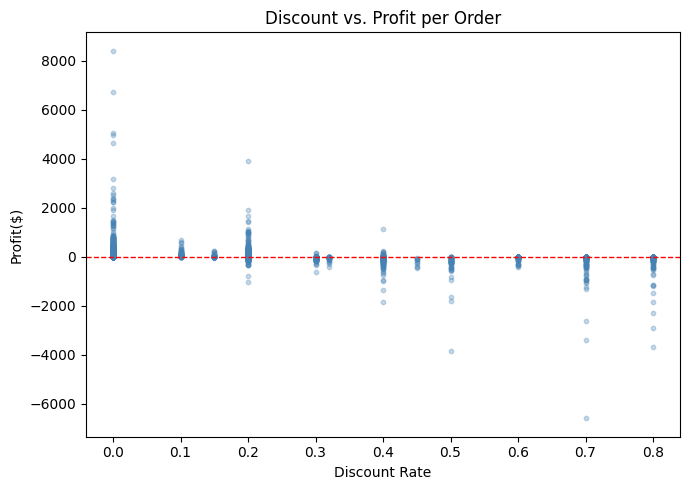

In [32]:
# To plot a scatter plot showing the above 

plt.figure(figsize=(7,5))
plt.scatter(df['Discount'], df['Profit'],alpha=0.3,s=10,color='steelblue')
plt.axhline(0,color='red',linestyle='--',linewidth = 1)
plt.title('Discount vs. Profit per Order')
plt.xlabel('Discount Rate')
plt.ylabel('Profit($)')
plt.tight_layout()
plt.show()

In [39]:
# WHICH CUSTOMER SEGMENT IS THE THE MOST VALUEABLE

seg = df.groupby('Segment').agg(
    Revenue = ('Sales','sum'),
    Profit = ('Profit','sum'),
    Orders = ('Order ID','nunique'),
    Customers = ('Customer ID','nunique')
).assign(
    profit_per_customer = lambda x: x['Profit']/x['Customers'],
    Avg_order_value = lambda x: x['Revenue']/x['Orders']
).reset_index()
print(seg)

       Segment       Revenue       Profit  Orders  Customers  \
0     Consumer  1.161401e+06  134119.2092    2586        409   
1    Corporate  7.061464e+05   91979.1340    1514        236   
2  Home Office  4.296531e+05   60298.6785     909        148   

   profit_per_customer  Avg_order_value  
0           327.919827       449.111116  
1           389.742093       466.411075  
2           407.423503       472.665730  


In [40]:
# TO CHECK REGIONAL PERFORMANCE 

region = df.groupby('Region').agg(
    sales=('Sales','sum'),
    profit=('Profit','sum'),
    margin = ('Profit Margin(%)','mean')
).reset_index()
print(region)

    Region        sales       profit     margin
0  Central  501239.8908   39706.3625 -10.407294
1     East  678781.2400   91522.7800  16.722696
2    South  391721.9050   46749.4303  16.351903
3     West  725457.8245  108418.4489  21.948662


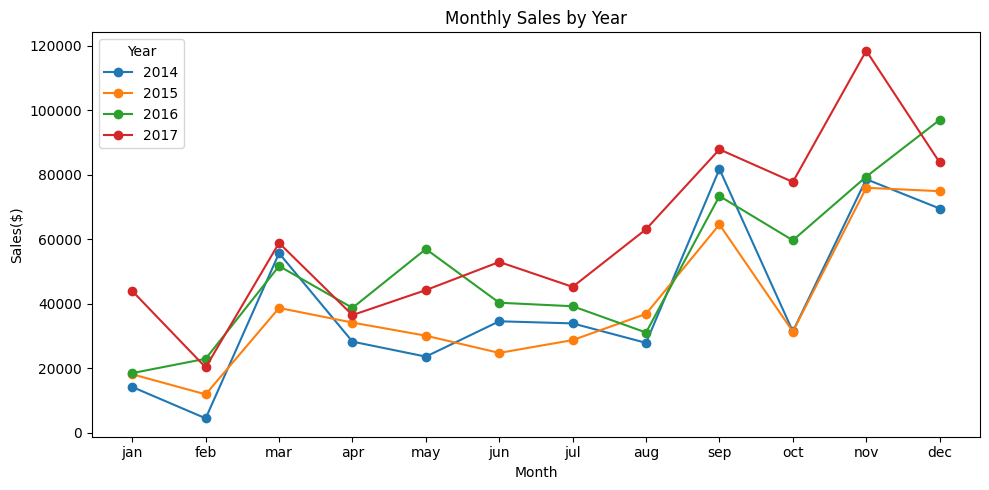

In [41]:
# MONTHLY SEASONALITY PATTERN

monthly = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly_pivot = monthly.pivot(index='Month',columns='Year',values ='Sales')
monthly_pivot.plot(figsize=(10,5),marker='o')
plt.title('Monthly Sales by Year')
plt.xlabel('Month')
plt.ylabel('Sales($)')
plt.xticks(range(1,13),['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'])
plt.tight_layout()
plt.show()

                    mean  median  count
Ship Mode                              
First Class     2.182705     2.0   1538
Same Day        0.044199     0.0    543
Second Class    3.238046     3.0   1945
Standard Class  5.006535     5.0   5968


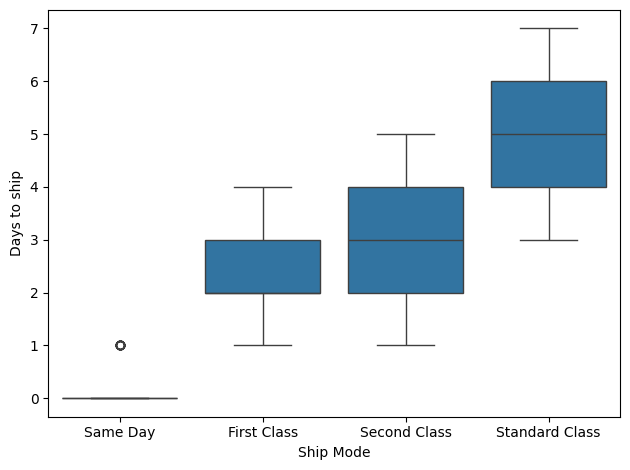

In [45]:
# HOW FAST DOES THE COMPANY SHIP ORDERS
import seaborn as sns
ship_analysis = df.groupby('Ship Mode')['Days to ship'].agg(['mean','median','count'])
print(ship_analysis)
sns.boxplot(data=df,x='Ship Mode', y='Days to ship',order=['Same Day','First Class','Second Class','Standard Class'])
plt.tight_layout()
plt.show()

In [50]:
# TOP 10 CONSUMERS BY PROFIT
top_customers = df.groupby('Customer Name').agg(
    sales=('Sales','sum'),
    profit=('Profit','sum'),
    orders=('Order ID','nunique')
).sort_values('profit',ascending=False).head(10)
print(top_customers)

                          sales     profit  orders
Customer Name                                     
Tamara Chand          19052.218  8981.3239       5
Raymond Buch          15117.339  6976.0959       6
Sanjit Chand          14142.334  5757.4119       9
Hunter Lopez          12873.298  5622.4292       6
Adrian Barton         14473.571  5444.8055      10
Tom Ashbrook          14595.620  4703.7883       4
Christopher Martinez   8954.020  3899.8904       4
Keith Dawkins          8181.256  3038.6254      12
Andy Reiter            6608.448  2884.6208       6
Daniel Raglin          8350.868  2869.0760       8


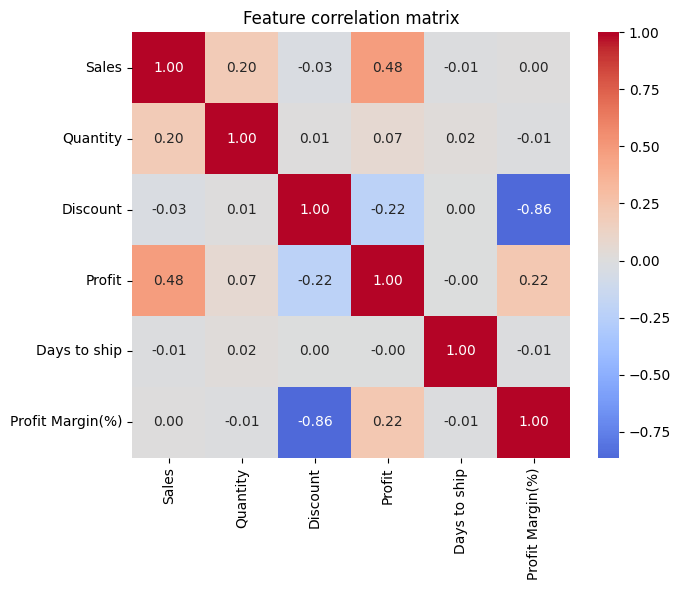

In [54]:
# CORRELATION AND STATISTICAL CHECKS
numeric_cols=['Sales','Quantity','Discount','Profit','Days to ship','Profit Margin(%)']
corr = df[numeric_cols].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()